1. Импортируем необходимые библиотеки

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

%matplotlib inline
sns.set_style("whitegrid")

2. Загрузка данных

In [67]:
df = pd.read_csv('heart.csv')
df.head(10)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


3. Информация о данных

In [68]:
df.shape

(303, 14)

4. Описание данных

In [69]:
df.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


5. Размер данных

In [70]:
rows, columns = df.shape
print(rows)
print(columns)


303
14


6. Проверка пропусков

In [71]:
df.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

7. Проверка дубликатов

In [72]:
df.duplicated().sum()

np.int64(1)

8. Удаление дубликатов

In [73]:
df = df.drop_duplicates().reset_index(drop=True)
df.duplicated().sum()

np.int64(0)

9. Проверка сбалансированности набора данных

In [74]:
(unique, counts) = np.unique(df['output'], return_counts=True)
print(unique)
print(counts)

[0 1]
[138 164]


10. Визуализация сбалансированности

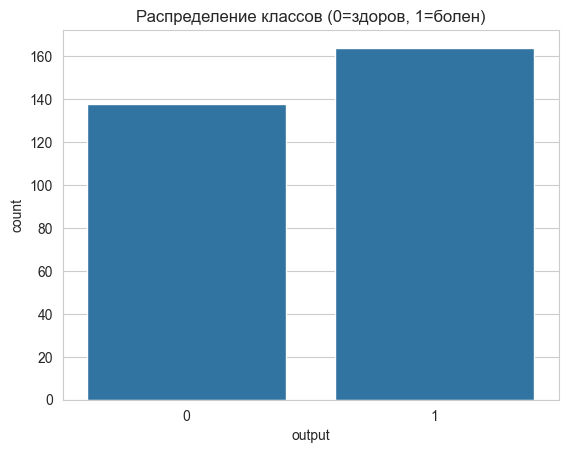

In [75]:
sns.countplot(df, x="output")
plt.title('Распределение классов (0=здоров, 1=болен)')
plt.show()

11.  Гистограммы распределения признаков

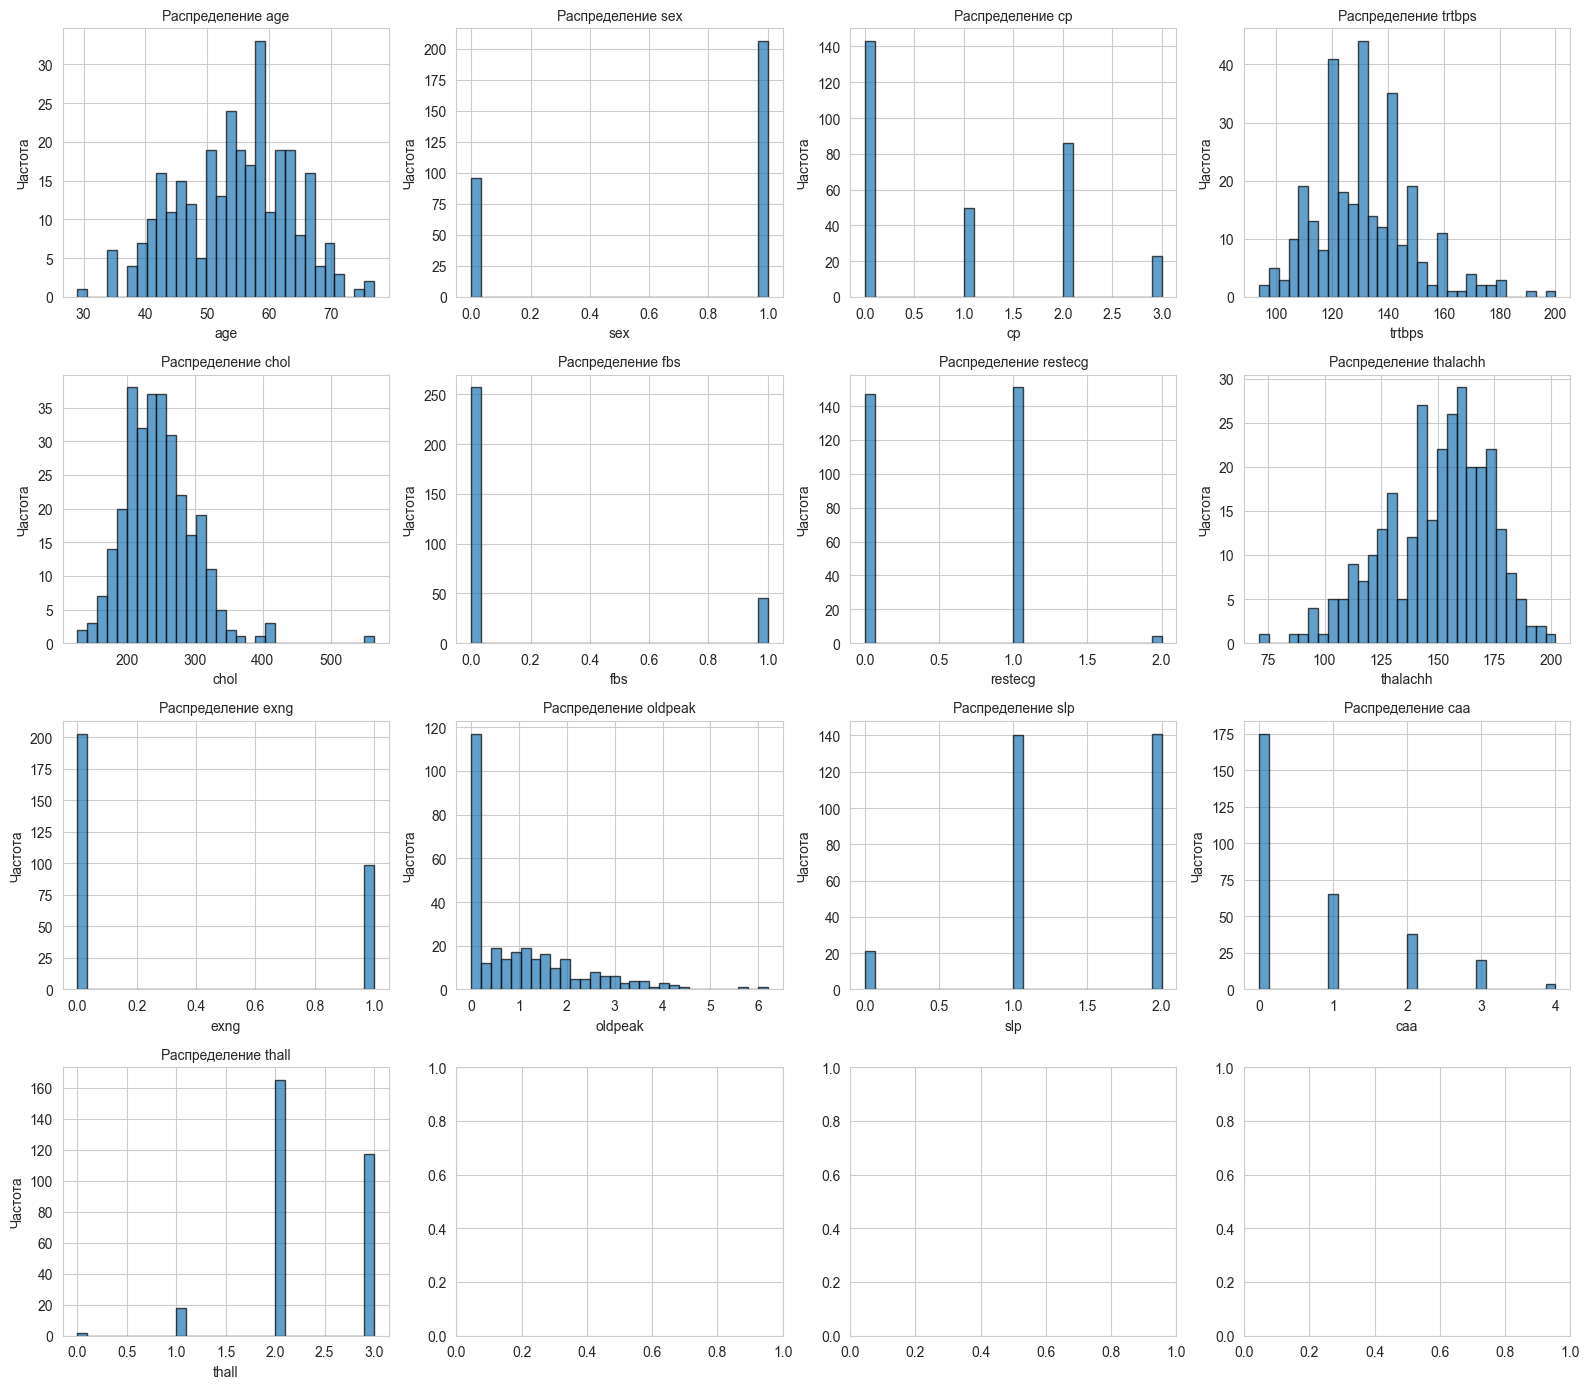

In [76]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
if 'output' in numeric_features:
    numeric_features.remove('output')

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    if i < len(axes):
        axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Распределение {col}', fontsize=10)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

12.  Распределение целевой переменной по полу


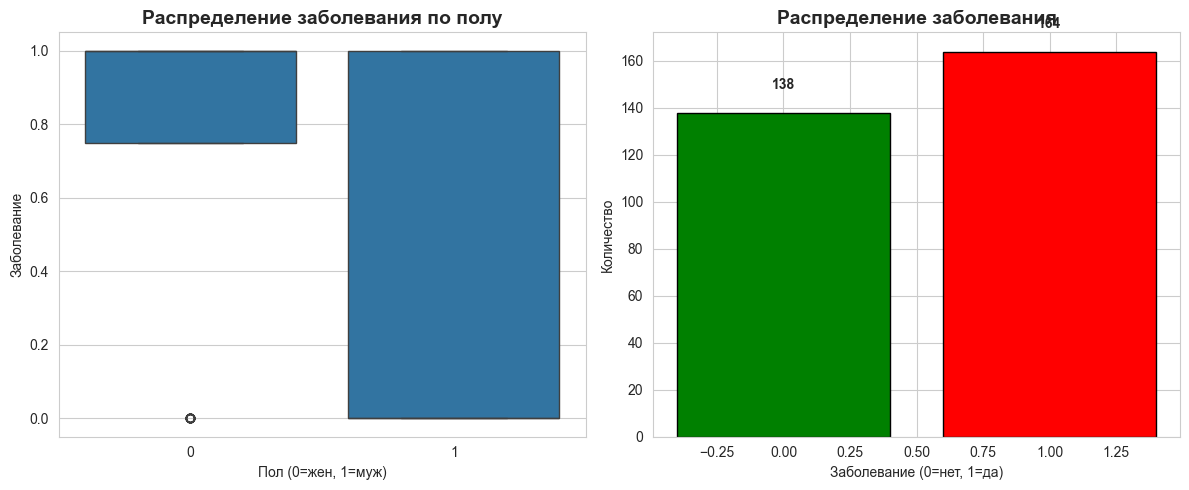

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='sex', y='output', ax=axes[0])
axes[0].set_title('Распределение заболевания по полу', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Пол (0=жен, 1=муж)')
axes[0].set_ylabel('Заболевание')

output_counts = df['output'].value_counts().sort_index()
axes[1].bar(output_counts.index, output_counts.values, color=['green', 'red'], edgecolor='black')
axes[1].set_title('Распределение заболевания', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Заболевание (0=нет, 1=да)')
axes[1].set_ylabel('Количество')
for i, v in enumerate(output_counts.values):
    axes[1].text(output_counts.index[i], v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

13. Матрица корреляций

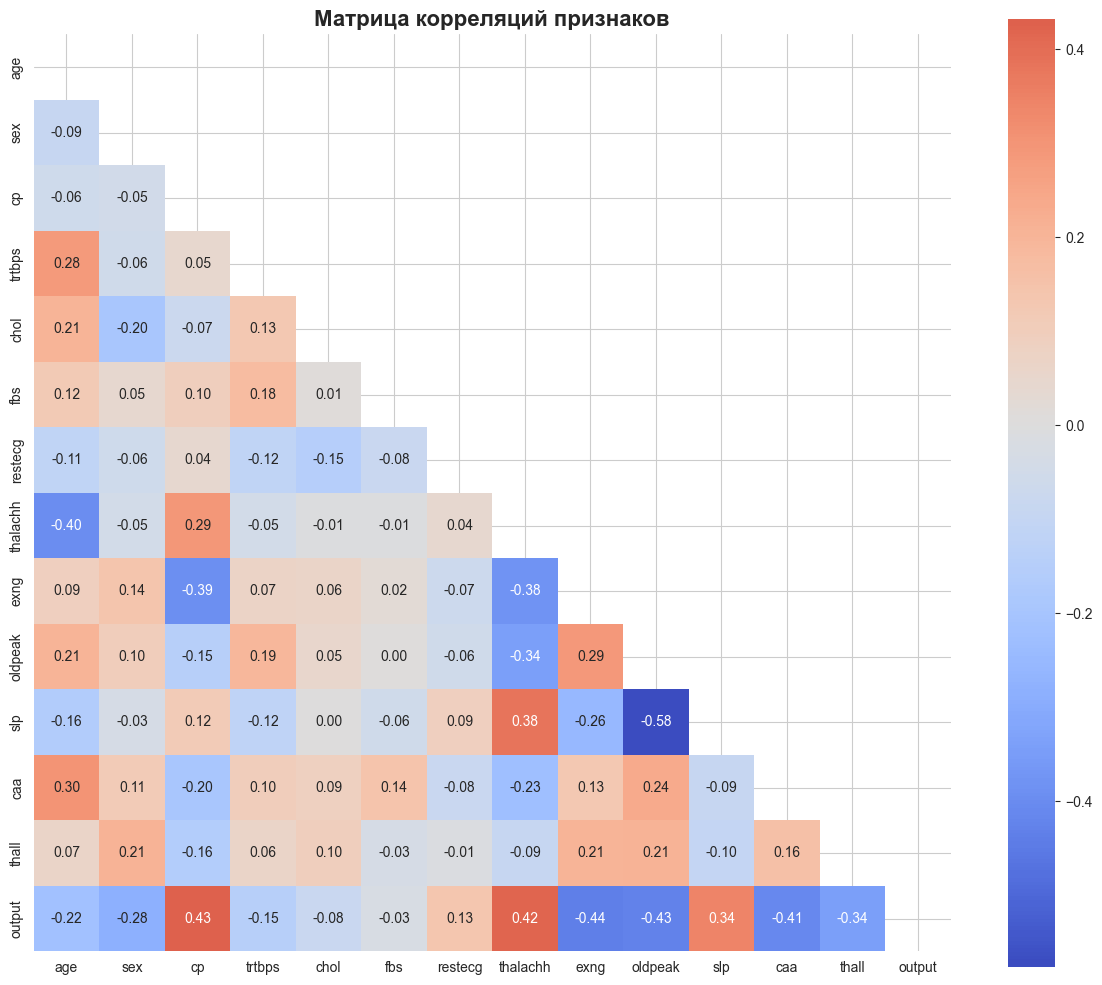

In [78]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, square=True)
plt.title('Матрица корреляций признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

14.   Корреляция признаков с целевой переменной

In [79]:
correlation_with_target = correlation_matrix['output'].abs().sort_values(ascending=False)
correlation_with_target[1:]

exng        0.435601
cp          0.432080
oldpeak     0.429146
thalachh    0.419955
caa         0.408992
slp         0.343940
thall       0.343101
sex         0.283609
age         0.221476
trtbps      0.146269
restecg     0.134874
chol        0.081437
fbs         0.026826
Name: output, dtype: float64

15.  Выводы о влиянии признаков

In [80]:
top_features = correlation_with_target[1:5]
print("Наиболее значимые признаки для определения заболевания:")
top_features

Наиболее значимые признаки для определения заболевания:


exng        0.435601
cp          0.432080
oldpeak     0.429146
thalachh    0.419955
Name: output, dtype: float64

16.  Предобработка данных - удаление слабо коррелирующих признаков

In [81]:
df_processed = df.copy()

low_corr_features = []
for feature, corr_value in correlation_with_target.items():
    if corr_value < 0.1 and feature != 'output':
        if feature in df.columns:
            low_corr_features.append(feature)

print(f"Удаляемые признаки (корреляция < 0.1): {low_corr_features}")
df_processed = df_processed.drop(columns=low_corr_features, errors='ignore')

Удаляемые признаки (корреляция < 0.1): ['chol', 'fbs']


17. Нормализация данных

In [82]:
scaler = StandardScaler()

numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'output']

df_processed[numeric_cols] = scaler.fit_transform(df_processed[numeric_cols])

print(f"\nРазмер датасета после предобработки: {df_processed.shape}")
print(f"Колонки после предобработки: {df_processed.columns.tolist()}")


Размер датасета после предобработки: (302, 12)
Колонки после предобработки: ['age', 'sex', 'cp', 'trtbps', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output']


18. Разделение на обучающую и тестовую выборки


In [83]:
X = df_processed.drop('output', axis=1)
y = df_processed['output']

(unique, counts) = np.unique(y, return_counts=True)
print(unique)
print(counts)

[0 1]
[138 164]


19. Train/test split

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (211, 11)
Размер тестовой выборки: (91, 11)


20. Обучение модели логистической регрессии

In [85]:
logreg = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

21. Предсказания

In [86]:
y_train_pred = logreg.predict(X_train)
y_test_pred = logreg.predict(X_test)

22. Матрица ошибок (обучающая выборка)

In [87]:
cm = confusion_matrix(y_train, y_train_pred)
TN, FP, FN, TP = confusion_matrix(y_train, y_train_pred).ravel()

print("TP = ", TP)
print("FP = ", FP)
print("TN = ", TN)
print("FN = ", FN)

accuracy = (TP + TN) / (TP + FP + TN + FN)
print("Accuracy = ", accuracy)

TP =  105
FP =  17
TN =  79
FN =  10
Accuracy =  0.8720379146919431


23. Точность на тестовой выборке

In [88]:
accuracy = accuracy_score(y_test, y_test_pred)
print("Accuracy = ", accuracy)

Accuracy =  0.8021978021978022


24. Визуализация матрицы ошибок

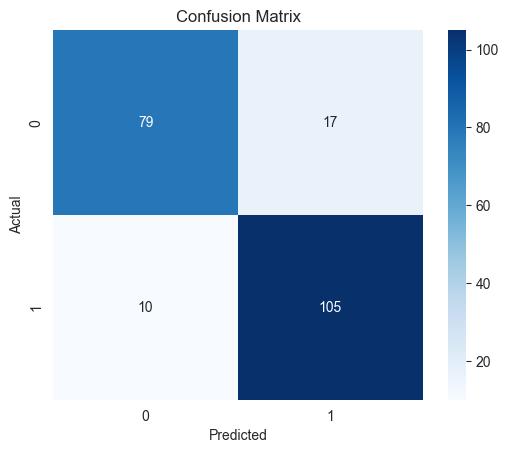

In [89]:
sns.heatmap(cm, square=True, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

25. Precision и Recall

In [90]:
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
print("Precision = ", precision)
print("Recall = ", recall)

Precision =  0.7719298245614035
Recall =  0.8979591836734694


26. F1 score

In [91]:
f1 = f1_score(y_test, y_test_pred)
print("F1 score = ", f1)

F1 score =  0.8301886792452831


27. ROC-кривая и AUC

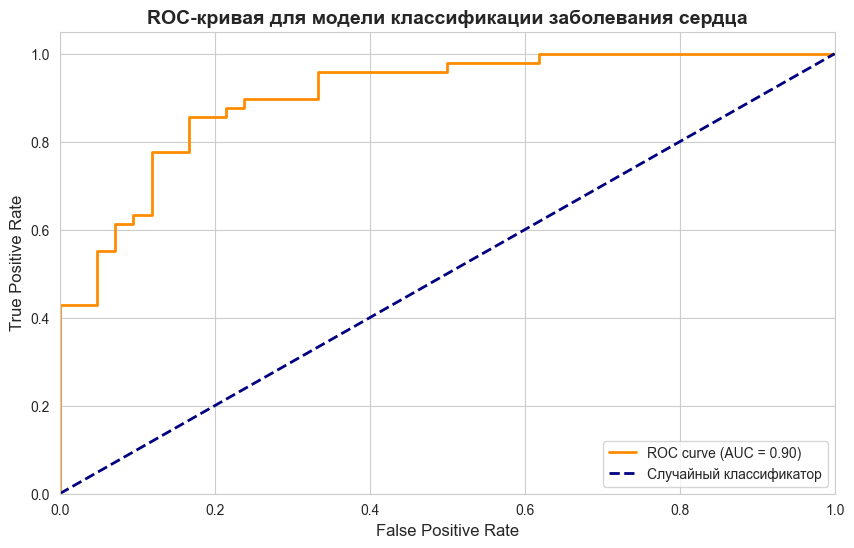

In [92]:
y_score = logreg.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds_test = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривая для модели классификации заболевания сердца', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

28. Коэффициенты модели

In [93]:
coef_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': logreg.coef_[0]
}).sort_values('Коэффициент', ascending=False)
print("Коэффициенты модели:")
coef_df

Коэффициенты модели:


,Признак,Коэффициент
2,cp,1.011144
5,thalachh,0.567892
8,slp,0.291954
4,restecg,0.243600
0,age,-0.049908
3,trtbps,-0.223722
6,exng,-0.486721
9,caa,-0.549733
10,thall,-0.614022
7,oldpeak,-0.646873
